# Benchmarking with MovieLens dataset

1. Popularity model as basline
2. Collaborative filtering
3. Neural ...

In [22]:
import torch as pt
from torch.utils.data import Dataset, DataLoader
from os.path import join
from collections import defaultdict
import random
import math
import matplotlib.pyplot as plt


pt.manual_seed(42)

DATASET = "ml-latest-small"
DATA_PATH_RAW = join('.', 'data', "raw", DATASET)
DATA_PATH_PRE = join('.', 'data', "preprocessed", DATASET)

In [23]:
# load pre-processed data 
data = pt.load(join(DATA_PATH_PRE, 'leave_one_out.pt'))

train_users = data["train_users"]
train_items = data["train_items"]
test_users  = data["test_users"]
test_items  = data["test_items"]
num_users   = data["num_users"]
num_items   = data["num_items"]

print("Train user Ids:", train_users)
print("Train item Ids:", train_items)
print("Number of users:", num_users)
print("Number of items:", num_items)

Train user Ids: tensor([  0,   0,   0,  ..., 609, 609, 609])
Train item Ids: tensor([   0,    1,    2,  ...,  113, 1491,  192])
Number of users: 610
Number of items: 9724


## 1. Popularity Model
This model simply ranks all of the items by their popularity, i.e. the number of user interactions. This is the baseline model, all other models should be better than this. The popularity array holds the number of pratings for each movie ID, which we can argsort to find the most popular movies in the training set. We use this ranking to predict the next ratings for each user in the test set assuming that popular movies in the train set will also be the most popular in the test set. 

Popularity models are based on the simple rationale: **“If I know absolutely nothing about this user, what should I show?”**

This is still a powerful baseline because real datasets have blockbusters and viral content and it makes sens to base a good amount of recommendations on global popularity. Therefore, they are used for:
- cold start (either of new users or the whole application)
- fallback mode
- sanity check (every more complex ML model must beat it)

The most popular items are:                 [15, 231, 170, 78, 213]
The most popular item has popularity:     [328, 315, 305, 278, 277]


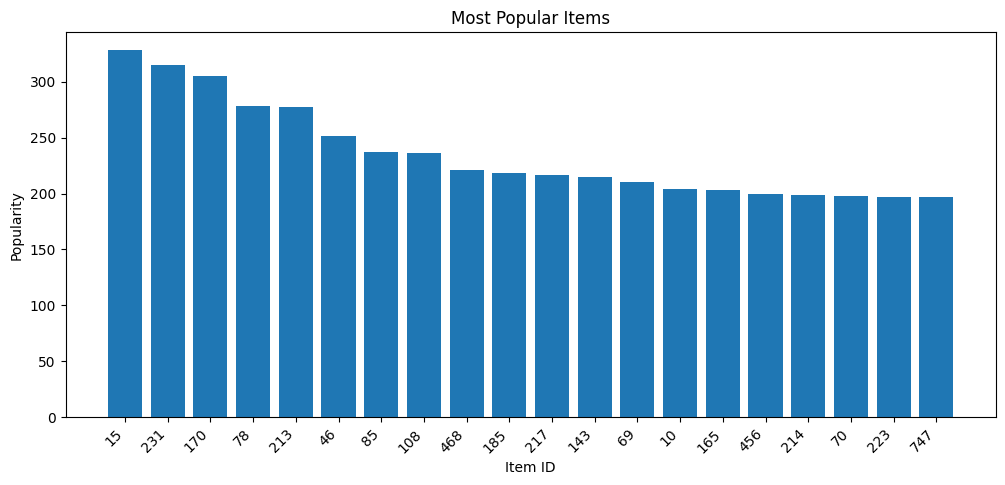

In [24]:
# get global item popularity by counting the number of interactions per item
popularity = pt.bincount(train_items, minlength=num_items)

# the popularity model is simply the items sorted by their popularity in descending order
popular_items = pt.argsort(popularity, descending=True) 

print("The most popular items are:                ", popular_items[0:5].tolist())
print("The most popular item has popularity:    ", popularity[popular_items[0:5]].tolist())

# visualize the popularity model with item IDs as x-axis labels
fig, ax = plt.subplots(figsize=(12, 5))
top_n = 20
ax.bar(range(top_n), popularity[popular_items[:top_n]].numpy())
ax.set_xlabel("Item ID")
ax.set_ylabel("Popularity")
ax.set_title("Most Popular Items")
ax.set_xticks(range(top_n))
ax.set_xticklabels([str(item.item()) for item in popular_items[:top_n]], rotation=45, ha='right')
plt.show()

In [25]:
def popularity_model(user_id, K=10):
    """ Recommend the top-k most popular items to the user he or she has not interacted with yet."""
    # empty recommendation list
    recs = []

    # get items the user has already interacted with
    user_train_items = train_items[train_users == user_id]

    # loop over popular items and add them to the recommendation list if the user has not interacted with them yet
    for item in popular_items:
        if item not in user_train_items:
            recs.append(item.item())
        if len(recs) == K:
            break
    return recs

popularity_model(40, K=5)

[231, 46, 85, 108, 468]